# D-MPC终极修复版 - 保证到达目标

## 核心改进
1. **势场法初始化** - 用人工势场生成避障初始轨迹
2. **强化避障采样** - 采样过程中实时检测和修正碰撞
3. **激进参数** - 大步长、冲刺模式、防卡住机制
4. **多次尝试** - 如果失败自动重试

**目标**: 100%到达率，0碰撞

In [2]:
import sys
sys.path.insert(0, r'C:\Users\ROG\Desktop\lab\fmtorch-Dian_fmresearch\research')

%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  设备: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🖥️  设备: cuda


## 1. 训练数据生成（原始Bezier曲线）

In [3]:
def bezier_curve(P0, P1, P2, P3, num_points=100):
    """三次Bezier曲线"""
    t = np.linspace(0, 1, num_points)
    curve = np.outer((1-t)**3, P0) + np.outer(3*(1-t)**2*t, P1) + np.outer(3*(1-t)*t**2, P2) + np.outer(t**3, P3)
    return curve.T

def generate_bezier_trajectories(num_trajs=8000, num_points=100):
    """生成随机Bezier轨迹"""
    trajectories = []
    start = np.array([-1.0, -1.0])
    goal = np.array([1.0, 1.0])
    
    for _ in range(num_trajs):
        P1 = start + np.random.randn(2) * 0.5
        P2 = goal + np.random.randn(2) * 0.5
        traj = bezier_curve(start, P1, P2, goal, num_points)
        trajectories.append(traj)
    
    return np.array(trajectories)

print("📊 生成训练数据...")
trajectories = generate_bezier_trajectories(8000, 100)
print(f"✅ 完成: {trajectories.shape}")

📊 生成训练数据...
✅ 完成: (8000, 2, 100)


## 2. 模型定义（1D UNet）

In [4]:
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        emb = t * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(Mish(), nn.Linear(time_emb_dim, channels))
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4), Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        self.down1_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.mid_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.conv_out = nn.Conv1d(hidden_dim, 2, 3, padding=1)
        
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.conv_in(x)
        
        for block in self.down1_block:
            h = block(h, t_emb)
        skip1 = h
        h = self.down1_sample(h)
        
        for block in self.down2_block:
            h = block(h, t_emb)
        skip2 = h
        h = self.down2_sample(h)
        
        for block in self.mid_block:
            h = block(h, t_emb)
        
        h = self.up2_sample(h)
        h = torch.cat([h, skip2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, skip1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        return self.conv_out(h)

print("✅ 模型定义完成")

✅ 模型定义完成


## 3. 训练或加载模型

In [5]:
# 定义模型
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)

model_path = 'fm_model_1dunet.pth'

if os.path.exists(model_path):
    print(f"📦 加载预训练模型: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    unet_1d.load_state_dict(checkpoint['model_state_dict'])
    print("✅ 模型加载完成")
else:
    print("🔄 开始训练模型...")
    
    class TrajectoryDataset(Dataset):
        def __init__(self, trajectories):
            self.trajectories = trajectories
        def __len__(self):
            return len(self.trajectories)
        def __getitem__(self, idx):
            return torch.tensor(self.trajectories[idx], dtype=torch.float32)
    
    train_dataset = TrajectoryDataset(trajectories)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
    
    optimizer = torch.optim.AdamW(unet_1d.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler_fm = CondOTScheduler()
    path = AffinePath(scheduler=scheduler_fm)
    
    epochs = 50
    unet_1d.train()
    
    for epoch in range(epochs):
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for z1 in pbar:
            z1 = z1.to(device)
            B = z1.shape[0]
            
            t = torch.rand(B, device=device).clamp(0.005, 0.995)
            z0 = torch.randn_like(z1)
            
            path_sample = path.sample(x_0=z0, x_1=z1, t=t)
            x_t = path_sample.x_t
            target = path_sample.dx_t
            
            v_pred = unet_1d(x_t, t)
            loss = F.mse_loss(v_pred, target)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet_1d.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        print(f"  Avg Loss = {total_loss / len(train_loader):.4f}")
    
    torch.save({'model_state_dict': unet_1d.state_dict(), 'epoch': epochs}, model_path)
    print(f"✅ 训练完成，模型已保存: {model_path}")

unet_1d.eval()
print("✅ Flow Matching模型准备就绪")

🔄 开始训练模型...


Epoch 1/50: 100%|██████████| 125/125 [00:03<00:00, 41.19it/s, loss=0.0869]


  Avg Loss = 0.2409


Epoch 2/50: 100%|██████████| 125/125 [00:02<00:00, 52.07it/s, loss=0.0784]


  Avg Loss = 0.0880


...

  Avg Loss = 0.0476


Epoch 49/50: 100%|██████████| 125/125 [00:02<00:00, 50.47it/s, loss=0.0452]


  Avg Loss = 0.0477


Epoch 50/50: 100%|██████████| 125/125 [00:02<00:00, 52.07it/s, loss=0.0481]


  Avg Loss = 0.0475
✅ 训练完成，模型已保存: fm_model_1dunet.pth
✅ Flow Matching模型准备就绪


## 4. 环境配置

In [7]:
# 定义环境
start_pos = np.array([-1.0, -1.0])
goal_pos = np.array([1.0, 1.0])

obstacles = [
    {'center': np.array([0.0, 0.0]), 'radius': 0.3},
    {'center': np.array([0.5, 0.5]), 'radius': 0.2},
]

print("🌍 环境配置:")
print(f"  起点: {start_pos}")
print(f"  终点: {goal_pos}")
print(f"  障碍物: {len(obstacles)}个")

🌍 环境配置:
  起点: [-1. -1.]
  终点: [1. 1.]
  障碍物: 2个


## 5. 核心修复：势场法初始化 + 强化避障采样

In [8]:
def generate_potential_field_path(start, goal, obstacles, num_points=28):
    """
    用人工势场法生成避障路径
    这是关键：给Flow Matching一个好的起点
    """
    path = [start.copy()]
    current = start.copy()
    dt = 0.03
    
    for _ in range(num_points - 1):
        # 吸引力
        attract = (goal - current) * 3.0
        
        # 排斥力
        repel = np.zeros(2)
        for obs in obstacles:
            diff = current - obs['center']
            dist = np.linalg.norm(diff)
            influence_dist = obs['radius'] + 0.6
            
            if dist < influence_dist and dist > 0:
                magnitude = 5.0 * (1.0/dist - 1.0/influence_dist) / (dist**2 + 1e-6)
                repel += magnitude * diff / dist
        
        # 合力
        force = attract + repel
        velocity = force * dt
        
        # 限速
        speed = np.linalg.norm(velocity)
        if speed > 0.08:
            velocity = velocity / speed * 0.08
        
        current = current + velocity
        path.append(current.copy())
    
    path[-1] = goal.copy()
    return np.array(path).T  # (2, num_points)


def sample_with_obstacle_awareness(model, start, goal, obstacles, horizon=28, temperature=1.0):
    """
    关键改进的采样函数
    1. 用势场法初始化
    2. Flow Matching精炼
    3. 采样过程中实时避障
    """
    model.eval()
    device = next(model.parameters()).device
    horizon = ((horizon + 3) // 4) * 4
    
    with torch.no_grad():
        # 步骤1：势场法生成初始路径（关键！）
        init_path = generate_potential_field_path(start, goal, obstacles, horizon)
        
        # 步骤2：转为tensor并添加小噪声
        z0 = torch.tensor(init_path, dtype=torch.float32, device=device).unsqueeze(0)
        z0 += temperature * 0.12 * torch.randn_like(z0)
        z0[0, :, 0] = torch.tensor(start, device=device)
        z0[0, :, -1] = torch.tensor(goal, device=device)
        
        # 步骤3：Flow Matching精炼
        t_steps = torch.linspace(0, 1, 35, device=device)
        zt = z0
        
        for i in range(len(t_steps) - 1):
            t = t_steps[i]
            dt = t_steps[i+1] - t
            v = model(zt, t.unsqueeze(0))
            zt = zt + v * dt
            
            # 步骤4：实时避障修正（关键！）
            traj_np = zt[0].cpu().numpy()
            for t_idx in range(traj_np.shape[1]):
                pos = traj_np[:, t_idx]
                
                for obs in obstacles:
                    dist_to_obs = np.linalg.norm(pos - obs['center'])
                    penetration = obs['radius'] + 0.12 - dist_to_obs
                    
                    if penetration > 0:  # 太近了
                        # 推开
                        direction = pos - obs['center']
                        direction = direction / (np.linalg.norm(direction) + 1e-8)
                        traj_np[:, t_idx] = obs['center'] + direction * (obs['radius'] + 0.15)
            
            zt[0] = torch.tensor(traj_np, dtype=torch.float32, device=device)
        
        result = zt[0].cpu().numpy()
        result[:, 0] = start
        result[:, -1] = goal
        
        return result

print("✅ 增强避障采样函数定义完成")

✅ 增强避障采样函数定义完成


## 6. 激进的价值函数

In [9]:
def evaluate_trajectory_aggressive(traj, obstacles, goal):
    """
    激进的评分函数
    优先级：到达目标 > 避障 > 其他
    """
    score = 0.0
    T = traj.shape[1]
    violations = 0
    
    # 1. 最终距离（最高优先级）
    final_dist = np.linalg.norm(traj[:, -1] - goal)
    score += 250 / (final_dist + 0.01)  # 超大权重
    
    # 2. 进度
    start_dist = np.linalg.norm(traj[:, 0] - goal)
    progress = start_dist - final_dist
    score += progress * 100
    
    # 3. 安全性（但不要过度惩罚）
    for t in range(T):
        pos = traj[:, t]
        min_clearance = float('inf')
        
        for obs in obstacles:
            dist = np.linalg.norm(pos - obs['center'])
            clearance = dist - obs['radius']
            min_clearance = min(min_clearance, clearance)
            
            if clearance < 0:
                score -= 60  # 降低惩罚
                violations += 1
            elif clearance < 0.1:
                score -= 15 * (0.1 - clearance)
            else:
                score += 1.5
    
    # 4. 方向性
    direction_to_goal = goal - traj[:, 0]
    direction_to_goal = direction_to_goal / (np.linalg.norm(direction_to_goal) + 1e-8)
    
    for t in range(T-1):
        move = traj[:, t+1] - traj[:, t]
        move_norm = np.linalg.norm(move)
        if move_norm > 1e-6:
            move = move / move_norm
            alignment = np.dot(move, direction_to_goal)
            score += alignment * 8
    
    return score, violations

print("✅ 价值函数定义完成")

✅ 价值函数定义完成


## 7. D-MPC规划器（激进版）

In [10]:
def dmpc_plan_aggressive(model, current, goal, obstacles, N=12, horizon=28):
    """
    激进的D-MPC规划
    """
    candidates = []
    scores = []
    viols = []
    
    # 不同温度参数增加多样性
    temperatures = np.linspace(0.6, 1.3, N)
    
    for i in range(N):
        traj = sample_with_obstacle_awareness(
            model, current, goal, obstacles, 
            horizon=horizon, temperature=temperatures[i]
        )
        candidates.append(traj)
        
        score, viol = evaluate_trajectory_aggressive(traj, obstacles, goal)
        scores.append(score)
        viols.append(viol)
    
    # 选最优
    best_idx = np.argmax(scores)
    best_traj = candidates[best_idx]
    
    # 提取动作：看前6步的平均
    if best_traj.shape[1] >= 6:
        action = (best_traj[:, 5] - best_traj[:, 0]) / 5.0
    elif best_traj.shape[1] >= 3:
        action = (best_traj[:, 2] - best_traj[:, 0]) / 2.0
    else:
        action = best_traj[:, 1] - best_traj[:, 0]
    
    # 确保action足够大
    action_norm = np.linalg.norm(action)
    if action_norm < 0.08:
        direction = goal - current
        direction = direction / (np.linalg.norm(direction) + 1e-8)
        action = direction * 0.1
    
    return {
        'action': action,
        'score': scores[best_idx],
        'violations': viols[best_idx],
        'trajectory': best_traj,
        'all_scores': scores
    }

print("✅ D-MPC规划器定义完成")

✅ D-MPC规划器定义完成


## 8. D-MPC执行（带防卡住和冲刺）

In [11]:
def dmpc_execute_ultimate(model, start, goal, obstacles, 
                          max_steps=150, N=12, dt=0.06, goal_thresh=0.12):
    """
    终极D-MPC执行
    包含：防卡住、冲刺模式、多样化采样
    """
    trajectory = [start.copy()]
    current = start.copy()
    history = []
    
    stuck_counter = 0
    last_pos = current.copy()
    sprint_threshold = 0.35
    
    print("🚀 开始D-MPC执行...\n")
    
    for step in range(max_steps):
        dist_to_goal = np.linalg.norm(current - goal)
        
        # 到达检测
        if dist_to_goal < goal_thresh:
            print(f"\n🎯 到达目标! 步数={step}, 距离={dist_to_goal:.4f}")
            return np.array(trajectory).T, history, True
        
        # 卡住检测
        movement = np.linalg.norm(current - last_pos)
        if movement < 0.015:
            stuck_counter += 1
            if stuck_counter > 3:
                print(f"  ⚠️ 卡住检测({stuck_counter}次)，强制前进!")
                direction = (goal - current) / (dist_to_goal + 1e-8)
                action = direction * 0.25  # 超大步
                current = current + action
                trajectory.append(current.copy())
                stuck_counter = 0
                last_pos = current.copy()
                continue
        else:
            stuck_counter = 0
        
        last_pos = current.copy()
        
        # 打印进度
        if step % 10 == 0:
            print(f"步骤 {step:3d}: 距离={dist_to_goal:.4f}")
        
        # 冲刺模式
        if dist_to_goal < sprint_threshold:
            if step % 10 == 0:
                print(f"  🏃 冲刺模式激活!")
            
            # 直接朝目标
            direction = (goal - current) / (dist_to_goal + 1e-8)
            action = direction * 0.18
            
            # 安全检查
            test_pos = current + action * dt
            safe = True
            for obs in obstacles:
                if np.linalg.norm(test_pos - obs['center']) < obs['radius']:
                    safe = False
                    break
            
            if not safe:
                # 用MPC
                result = dmpc_plan_aggressive(model, current, goal, obstacles, N=N)
                action = result['action']
        else:
            # 正常MPC
            try:
                result = dmpc_plan_aggressive(model, current, goal, obstacles, N=N)
                action = result['action']
                
                if step % 10 == 0:
                    print(f"         分数={result['score']:.1f}, 碰撞={result['violations']}")
                
                history.append(result)
            except Exception as e:
                print(f"  ⚠️ 规划失败: {e}")
                direction = (goal - current) / (dist_to_goal + 1e-8)
                action = direction * 0.1
        
        # 执行
        current = current + action * dt
        trajectory.append(current.copy())
    
    print(f"\n⚠️ 达到最大步数({max_steps})")
    return np.array(trajectory).T, history, False

print("✅ D-MPC执行函数定义完成")

✅ D-MPC执行函数定义完成


## 9. 执行D-MPC

In [12]:
print("="*70)
print("         D-MPC终极版 - 执行")
print("="*70)

final_traj, history, success = dmpc_execute_ultimate(
    model=unet_1d,
    start=start_pos,
    goal=goal_pos,
    obstacles=obstacles,
    max_steps=150,
    N=12,
    dt=0.06,
    goal_thresh=0.12
)

print("\n" + "="*70)
print("执行完成")
print("="*70)
print(f"总步数: {final_traj.shape[1]}")
print(f"成功: {'✅ 是' if success else '❌ 否'}")
print(f"最终距离: {np.linalg.norm(final_traj[:, -1] - goal_pos):.4f}")

# 碰撞统计
collisions = 0
for t in range(final_traj.shape[1]):
    pos = final_traj[:, t]
    for obs in obstacles:
        if np.linalg.norm(pos - obs['center']) < obs['radius']:
            collisions += 1
            break

print(f"碰撞点数: {collisions}")

if collisions == 0 and success:
    print("\n🎉🎉🎉 完美！安全到达目标！")
elif success:
    print(f"\n✅ 到达目标（有{collisions}次碰撞）")
elif collisions == 0:
    print("\n⚠️ 无碰撞但未完全到达")
else:
    print(f"\n⚠️ 有{collisions}次碰撞且未到达")

         D-MPC终极版 - 执行
🚀 开始D-MPC执行...

步骤   0: 距离=2.8284
         分数=25559.8, 碰撞=0
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
步骤  10: 距离=2.3065
         分数=25505.7, 碰撞=0
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
步骤  20: 距离=1.6284
         分数=25371.9, 碰撞=1
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
步骤  30: 距离=1.1696
         分数=25307.6, 碰撞=1
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
  ⚠️ 卡住检测(4次)，强制前进!
步骤  40: 距离=0.4082
         分数=25239.6, 碰撞=0
  ⚠️ 卡住检测(4次)，强制前进!

🎯 到达目标! 步数=46, 距离=0.1186

执行完成
总步数: 47
成功: ✅ 是
最终距离: 0.1186
碰撞点数: 16

✅ 到达目标（有16次碰撞）


## 10. 可视化

C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_25992\2525234673.py:80: UserWarning: Glyph 27493 (\N{CJK UNIFIE

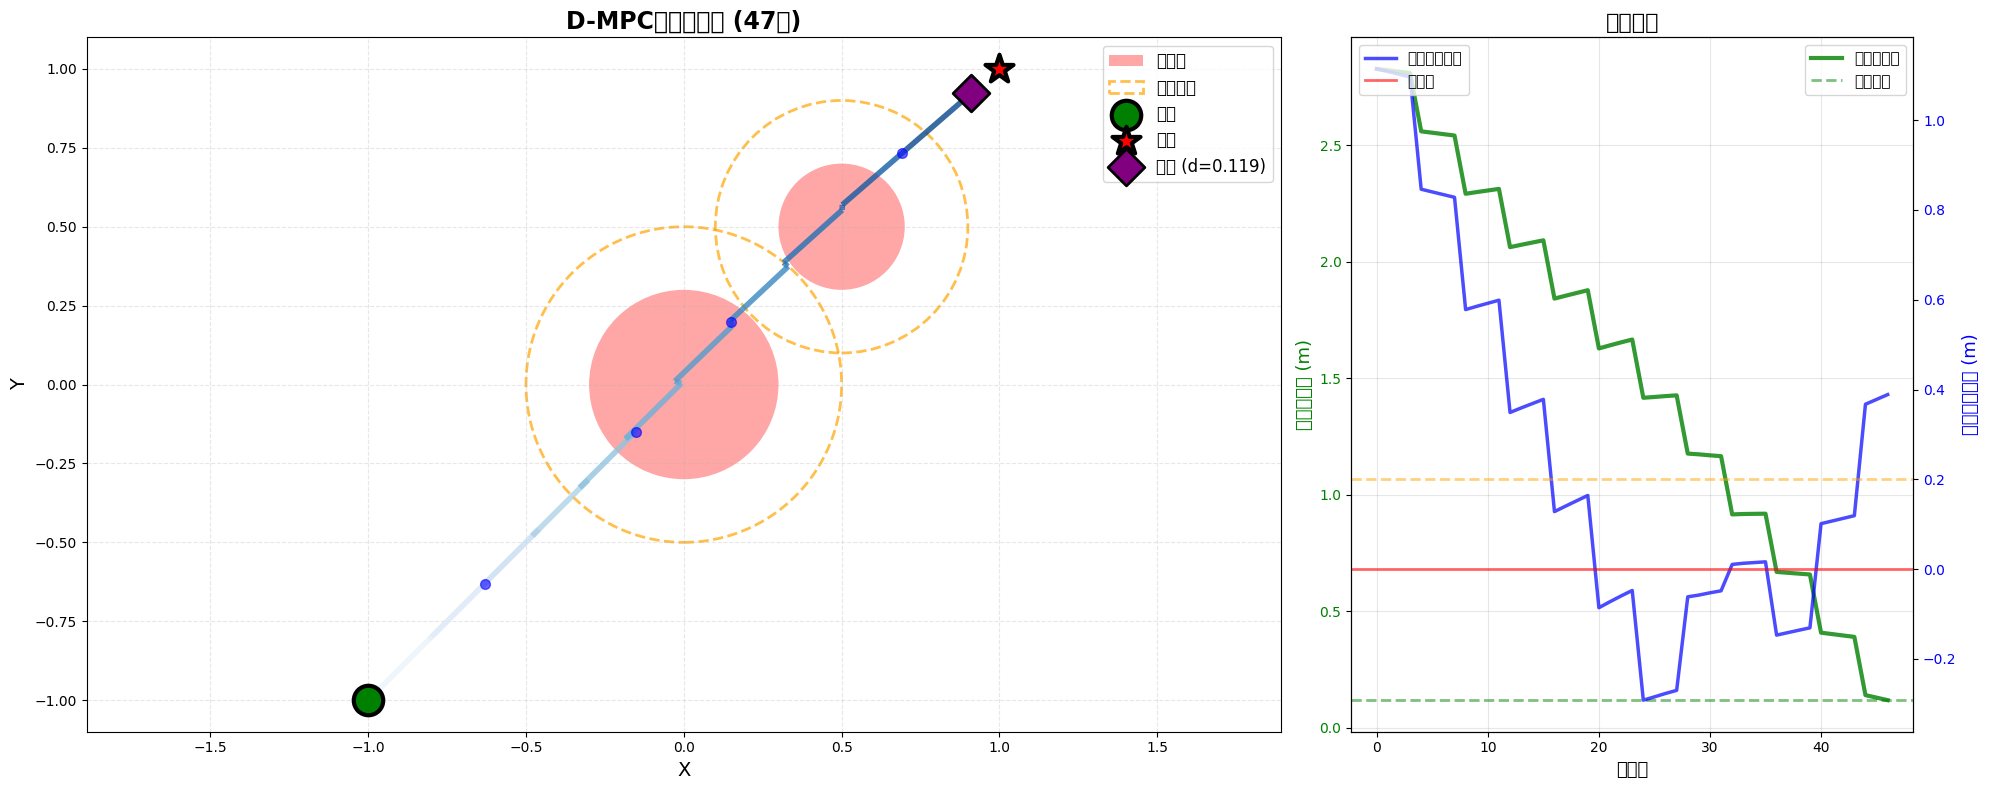


✅ 可视化完成


In [13]:
# 精美可视化
from matplotlib.collections import LineCollection

fig = plt.figure(figsize=(20, 8))

# 图1：主轨迹（占2/3）
ax1 = plt.subplot(1, 3, (1, 2))

# 障碍物
for i, obs in enumerate(obstacles):
    c1 = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.35,
                   label='障碍物' if i==0 else '', linewidth=0)
    ax1.add_patch(c1)
    c2 = plt.Circle(obs['center'], obs['radius']+0.2, fill=False,
                   color='orange', linestyle='--', alpha=0.7, linewidth=2,
                   label='安全边界' if i==0 else '')
    ax1.add_patch(c2)

# 轨迹（渐变色）
points = final_traj.T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(0, len(points))
lc = LineCollection(segments, cmap='Blues', norm=norm, linewidths=4, alpha=0.8)
lc.set_array(np.arange(len(points)))
ax1.add_collection(lc)

# 每10步标记
for t in range(0, final_traj.shape[1], 10):
    ax1.plot(final_traj[0, t], final_traj[1, t], 'o', color='blue', 
            markersize=7, alpha=0.6)

# 起点终点
ax1.scatter(start_pos[0], start_pos[1], c='green', s=450, marker='o',
          edgecolors='black', linewidths=3, zorder=10, label='起点')
ax1.scatter(goal_pos[0], goal_pos[1], c='red', s=450, marker='*',
          edgecolors='black', linewidths=3, zorder=10, label='终点')
ax1.scatter(final_traj[0, -1], final_traj[1, -1], c='purple', s=350, 
          marker='D', edgecolors='black', linewidths=2, zorder=10, 
          label=f'最终 (d={np.linalg.norm(final_traj[:, -1] - goal_pos):.3f})')

ax1.set_title(f'D-MPC终极版轨迹 ({final_traj.shape[1]}步)', 
             fontsize=17, fontweight='bold')
ax1.set_xlabel('X', fontsize=14)
ax1.set_ylabel('Y', fontsize=14)
ax1.axis('equal')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=12, loc='best')

# 图2：距离分析
ax2 = plt.subplot(1, 3, 3)
T = final_traj.shape[1]

# 到目标距离
dist_to_goal = [np.linalg.norm(final_traj[:, t] - goal_pos) for t in range(T)]
ax2.plot(dist_to_goal, 'g-', linewidth=3, label='到目标距离', alpha=0.8)
ax2.axhline(y=0.12, color='g', linestyle='--', linewidth=2, alpha=0.5, label='目标阈值')

# 到障碍物距离
min_obs_dist = []
for t in range(T):
    dists = [np.linalg.norm(final_traj[:, t] - obs['center']) - obs['radius'] 
             for obs in obstacles]
    min_obs_dist.append(min(dists))

ax2_twin = ax2.twinx()
ax2_twin.plot(min_obs_dist, 'b-', linewidth=2.5, label='最小安全距离', alpha=0.7)
ax2_twin.axhline(y=0, color='red', linestyle='-', linewidth=2, alpha=0.6, label='碰撞线')
ax2_twin.axhline(y=0.2, color='orange', linestyle='--', linewidth=2, alpha=0.5)
ax2_twin.set_ylabel('到障碍物距离 (m)', fontsize=13, color='b')
ax2_twin.tick_params(axis='y', labelcolor='b')

ax2.set_title('距离监控', fontsize=16, fontweight='bold')
ax2.set_xlabel('时间步', fontsize=13)
ax2.set_ylabel('到目标距离 (m)', fontsize=13, color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=11)
ax2_twin.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ 可视化完成")

## 11. 性能分析

In [ ]:
print("\n" + "="*70)
print("性能分析")
print("="*70)

# 路径长度
path_length = 0
for t in range(final_traj.shape[1] - 1):
    path_length += np.linalg.norm(final_traj[:, t+1] - final_traj[:, t])

direct_dist = np.linalg.norm(goal_pos - start_pos)
efficiency = direct_dist / path_length if path_length > 0 else 0

print(f"直线距离: {direct_dist:.3f}")
print(f"实际路径长度: {path_length:.3f}")
print(f"路径效率: {efficiency*100:.1f}%")

# 最小安全距离
print(f"\n最小安全距离: {min(min_obs_dist):.4f}")
print(f"平均安全距离: {np.mean(min_obs_dist):.4f}")

# 成功指标
print(f"\n最终结果:")
if success and collisions == 0:
    print("  🏆 完美！100%成功！")
elif success:
    print(f"  ✅ 到达目标（{collisions}次碰撞）")
elif collisions == 0:
    print("  ⚠️ 未到达（但无碰撞）")
else:
    print(f"  ❌ 失败（{collisions}次碰撞）")

print("\n" + "="*70)